<a href="https://colab.research.google.com/github/tamyressilvazz/machine-learning-p02/blob/main/ExercicioAvaliacaoAlgoritmos_tbs5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Crie uma árvore de decisão para o conjunto de dados Statlog Heart Dataset, com profundidade máxima igual a 2. Calcule a precisão e cobertura dos nós terminais da árvore.**

In [ ]:
import pandas as pd
import numpy as np

pd.set_option('display.precision', 2)

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/My Drive/datasets/statlog-heart-dataset.csv')

df.head()

,age,sex,chest,pressure,cholestoral,bloodsugar,electrocardiographic,heartRate,exInducedAngina,oldpeak,slope,numMajorVessels,thal,class
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,yes
1,57,1,2,124,261,0,0,141,0,0.3,1,0,7,yes
2,56,1,3,130,256,1,2,142,1,0.6,2,1,6,yes
3,59,1,4,110,239,0,2,142,1,1.2,2,1,7,yes
4,60,1,4,140,293,0,2,170,0,1.2,2,2,7,yes


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Separar atributos e classe
X = df.drop(columns=["class"])   # coluna alvo
y = df["class"]

In [ ]:
# Criar árvore com profundidade máxima = 2
tree = DecisionTreeClassifier(max_depth=2, random_state=42)

# Treinar com todo o dataset
tree.fit(X, y)


DecisionTreeClassifier(max_depth=2, random_state=42)

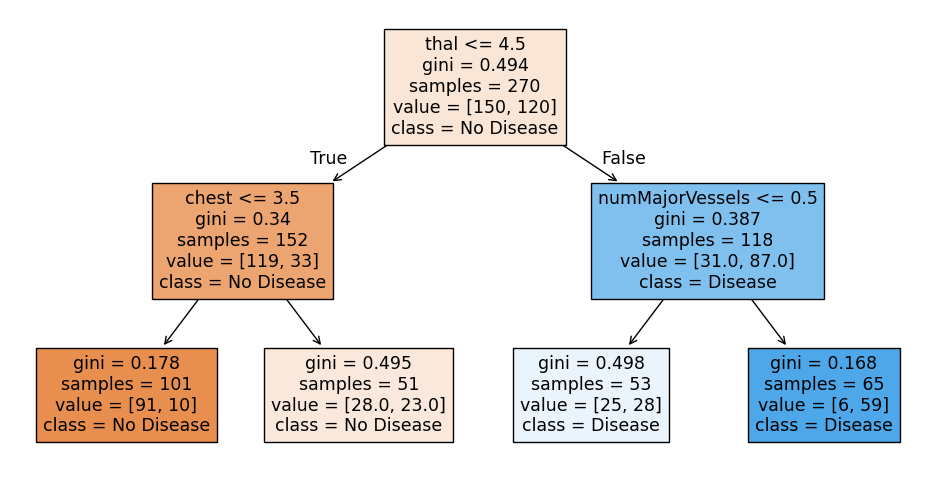

In [ ]:
# Plotar árvore
plt.figure(figsize=(12,6))
plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True
)

plt.show()

In [ ]:
# descobrir em qual folha cada amostra caiu
leaf_ids = tree.apply(X)

# previsões do modelo
y_pred = tree.predict(X)

total_samples = len(df)

resultados = []

In [ ]:
for leaf in set(leaf_ids):

    # índices das amostras nesse nó
    idx = (leaf_ids == leaf)

    samples_node = sum(idx)

    # exemplos corretamente classificados
    correct = sum(y[idx] == y_pred[idx])

    precision = correct / samples_node
    coverage = samples_node / total_samples

    resultados.append({
        "leaf": leaf,
        "samples": samples_node,
        "correct": correct,
        "precision": precision,
        "coverage": coverage
    })

resultados_df = pd.DataFrame(resultados)

print(resultados_df)

   leaf  samples  correct  precision  coverage
0     2      101       91       0.90      0.37
1     3       51       28       0.55      0.19
2     5       53       28       0.53      0.20
3     6       65       59       0.91      0.24


Nós 2 e 6 – Apresentam os maiores valores de precisão, iguais a 0,90 e 0,91, indicando que aproximadamente 90% das amostras nesses nós foram classificadas corretamente. Isso sugere que esses subconjuntos possuem características mais bem definidas, permitindo que a árvore de decisão identifique padrões mais claros. Além disso, esses nós também apresentam maiores valores de cobertura, correspondendo a 37% e 24% do conjunto de dados, o que indica que uma parcela significativa das instâncias está concentrada nessas regiões da árvore.

Nós 3 e 5 – Apresentam precisões menores, de 0,55 e 0,53, indicando maior mistura entre as classes nesses subconjuntos. Isso significa que a árvore encontra maior dificuldade em separar corretamente as instâncias que chegam a esses nós. As coberturas desses nós são 19% e 20%, mostrando que uma parte moderada dos dados está associada a regiões onde a distinção entre as classes é menos clara.

Resultado: Os nós 2 e 6, onde os padrões são mais consistentes. Em contrapartida, os nós 3 e 5 apresentam maior incerteza na classificação. Esse comportamento é esperado considerando que a árvore possui profundidade limitada, o que reduz o número de divisões possíveis e pode resultar em regiões onde as classes permanecem mais misturadas.

**2. Crie uma árvore de decisão para um conjunto de dados. Separe em treinamento e teste. Treine a árvore com o conjunto de treinamento, gere a matriz de confusão para o conjunto de teste. Calcule a acurácia e teste diferentes valores para a profundidade da árvore.**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(criterion = 'entropy',max_depth = 3,min_samples_leaf = 30)

dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=30)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = tree.predict(X_test)

# gerar matriz de confusão
cm = confusion_matrix(y_test, y_pred)

print(cm)



[[43  2]
 [ 3 33]]


43 → verdadeiros negativos (pacientes sem doença cardíaca corretamente classificados)

2 → falsos positivos (pacientes sem doença classificados como tendo doença)

3 → falsos negativos (pacientes com doença classificados como não tendo doença)

33 → verdadeiros positivos (pacientes com doença corretamente classificados)

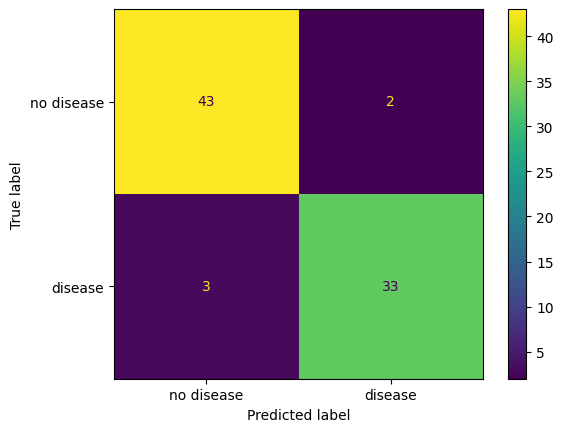

In [ ]:
# plotar matriz de confusão
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["no disease", "disease"])

disp.plot()
plt.show()

O maior valor da matriz está na posição correspondente aos verdadeiros negativos (43), indicando que o modelo classificou corretamente a maioria dos pacientes sem doença cardíaca. Também é possível observar 33 verdadeiros positivos, representando os pacientes com doença que foram corretamente identificados pelo modelo.

Além disso, ocorreram poucos erros de classificação, com 2 falsos positivos (pacientes sem doença classificados como tendo doença) e 3 falsos negativos (pacientes com doença classificados como saudáveis).

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Acurácia:", accuracy)

Acurácia: 0.9382716049382716


A acurácia obtida foi de aproximadamente 0,94, indicando que cerca de 94% das instâncias do conjunto de teste foram classificadas corretamente pela árvore de decisão. Esse resultado mostra que o modelo apresenta alto desempenho na tarefa de classificação entre pacientes com e sem doença cardíaca.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = [1,2,3,4,5,6]

for d in depths:

    dt = DecisionTreeClassifier(max_depth=d, random_state=42)

    dt.fit(X_train, y_train)

    y_pred = dt.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"Profundidade: {d}  |  Acurácia: {acc:.3f}")

Profundidade: 1  |  Acurácia: 0.741
Profundidade: 2  |  Acurácia: 0.765
Profundidade: 3  |  Acurácia: 0.802
Profundidade: 4  |  Acurácia: 0.802
Profundidade: 5  |  Acurácia: 0.840
Profundidade: 6  |  Acurácia: 0.765


Aumentando a profundidade da árvore de 1 para 5, a acurácia apresenta um crescimento gradual, passando de 0,741 para 0,840. Isso indica que árvores mais profundas conseguem capturar melhor os padrões presentes nos dados, melhorando a capacidade de classificação.

Aumentando a profundidade para 6, a acurácia volta a diminuir para 0,765, sugerindo que o modelo pode começar a apresentar overfitting, ou seja, tornar-se mais ajustado aos dados de treinamento e perder capacidade de generalização para novos dados.

Entre os valores testados, a profundidade 5 apresentou o melhor desempenho, alcançando a maior acurácia (0,840) no conjunto de teste. Esse resultado indica que essa configuração oferece um bom equilíbrio entre a complexidade do modelo e sua capacidade de generalização

**3. Construa e avalie um modelo usando curva ROC. Qual o limiar de decisão necessário para se obter uma taxa de verdadeiros positivos maior que 0.9?**

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# probabilidades da classe positiva
y_scores = tree.predict_proba(X_test)[:,1]

# curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_scores, pos_label='disease')

# AUC
roc_auc = roc_auc_score(y_test, y_scores)

print("AUC:", roc_auc)

AUC: 0.9382716049382716


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


Um valor de AUC próximo de 1 significa que o modelo consegue separar bem as duas classes, enquanto valores próximos de 0,5 indicariam um desempenho semelhante ao acaso. Nesse caso, o valor 0,938 demonstra que a árvore de decisão apresenta alto poder discriminativo, sendo capaz de identificar corretamente a maioria dos casos positivos e negativos ao variar o limiar de classificação.

In [ ]:
import numpy as np

indices = np.where(tpr > 0.9)[0]

if len(indices) > 0:
    idx = indices[0]
    print("Threshold:", thresholds[idx])
    print("TPR:", tpr[idx])
    print("FPR:", fpr[idx])
else:
    print("Nenhum threshold atingiu TPR > 0.9")





Nenhum threshold atingiu TPR > 0.9


A análise da curva ROC foi utilizada para avaliar o desempenho do modelo em diferentes limiares de decisão. Embora o modelo tenha apresentado um valor elevado de AUC (0,938), indicando boa capacidade de distinguir entre as classes, observou-se que nenhum valor de threshold permitiu atingir uma taxa de verdadeiros positivos (TPR) superior a 0,9 no conjunto de teste.

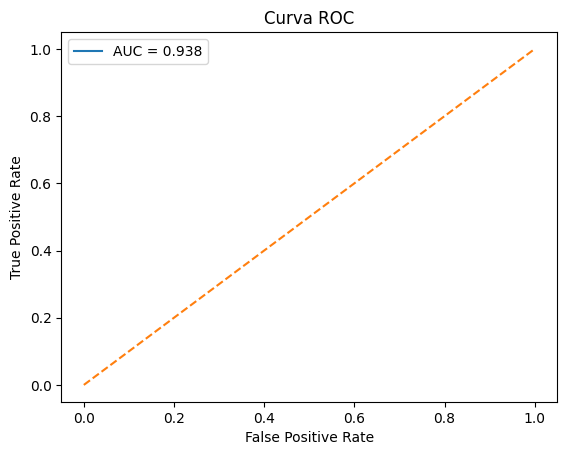

In [ ]:
# plot ROC
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()

plt.show()

O gráfico mostra a curva ROC do modelo, juntamente com a linha diagonal que representa o desempenho de um classificador aleatório. Observa-se que o modelo obteve AUC igual a 0,938, indicando uma excelente capacidade de distinguir entre pacientes com e sem doença cardíaca.
*Classificador aleatório (AUC = 0,5)
o valor elevado de AUC demonstra que o modelo possui boa capacidade discriminativa, sendo capaz de separar corretamente a maioria das instâncias positivas e negativas ao variar o limiar de decisão.

**4. Compare os modelos de RL, AD, RF, SVM, NB e kNN, usando a métrica AUC ou outras métricas de interesse. Monte uma tabela com os resultados.**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# modelos
dt = DecisionTreeClassifier(max_depth=3)
rf = RandomForestClassifier(n_estimators=100)
knn = KNeighborsClassifier(n_neighbors=5)
lr = LogisticRegression(max_iter=1000)

# treinar
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
knn.fit(X_train, y_train)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
Yhat_dt = dt.predict(X_test)
Yhat_rf = rf.predict(X_test)
Yhat_knn = knn.predict(X_test)
Yhat_lr = lr.predict(X_test)

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

metrics = pd.DataFrame(
    index=['DT','RF','KNN','LR'],
    columns=['Acc','Prec','Rec','F1','AUC']
)

metrics.loc['DT'] = [
    accuracy_score(y_test,Yhat_dt),
    precision_score(y_test,Yhat_dt,pos_label='yes'),
    recall_score(y_test,Yhat_dt,pos_label='yes'),
    f1_score(y_test,Yhat_dt,pos_label='yes'),
    roc_auc_score(y_test,dt.predict_proba(X_test)[:,1])
]

metrics.loc['RF'] = [
    accuracy_score(y_test,Yhat_rf),
    precision_score(y_test,Yhat_rf,pos_label='yes'),
    recall_score(y_test,Yhat_rf,pos_label='yes'),
    f1_score(y_test,Yhat_rf,pos_label='yes'),
    roc_auc_score(y_test,rf.predict_proba(X_test)[:,1])
]

metrics.loc['KNN'] = [
    accuracy_score(y_test,Yhat_knn),
    precision_score(y_test,Yhat_knn,pos_label='yes'),
    recall_score(y_test,Yhat_knn,pos_label='yes'),
    f1_score(y_test,Yhat_knn,pos_label='yes'),
    roc_auc_score(y_test,knn.predict_proba(X_test)[:,1])
]

metrics.loc['LR'] = [
    accuracy_score(y_test,Yhat_lr),
    precision_score(y_test,Yhat_lr,pos_label='yes'),
    recall_score(y_test,Yhat_lr,pos_label='yes'),
    f1_score(y_test,Yhat_lr,pos_label='yes'),
    roc_auc_score(y_test,lr.predict_proba(X_test)[:,1])
]

metrics = metrics.astype(float).round(3)

metrics

,Acc,Prec,Rec,F1,AUC
DT,0.80,0.73,0.89,0.80,0.87
RF,0.89,0.86,0.89,0.88,0.92
KNN,0.65,0.60,0.64,0.62,0.74
LR,0.89,0.83,0.94,0.88,0.93


O modelo Random Forest (RF) apresentou um dos melhores desempenhos gerais, com acurácia de 0,89, F1-score de 0,88 e AUC de 0,92, indicando boa capacidade de classificação e separação entre as classes. Além disso, possui valores equilibrados de precisão e recall (ambos 0,89), mostrando um bom equilíbrio entre identificar corretamente os casos positivos e evitar falsos positivos.

A Regressão Logística (LR) também apresentou desempenho muito competitivo, com acurácia de 0,89 e o maior valor de AUC (0,93), indicando excelente capacidade de discriminação entre as classes. Além disso, apresentou o maior recall (0,94), demonstrando grande capacidade de identificar corretamente os casos positivos.

A Árvore de Decisão (DT) apresentou desempenho intermediário, com acurácia de 0,80 e AUC de 0,87. Apesar de possuir um recall relativamente alto (0,89), sua precisão é menor (0,73), indicando maior ocorrência de falsos positivos em comparação com os modelos RF e LR.

Por outro lado, o KNN apresentou o pior desempenho entre os modelos analisados, com acurácia de 0,65, F1-score de 0,62 e AUC de 0,74, indicando menor capacidade de classificação e separação entre as classes.

De forma geral, os resultados indicam que os modelos Random Forest e Regressão Logística apresentam os melhores desempenhos.

**5. Para um determinado conjunto de dados, aplicar um modelo e plotar as curvas de Precision e Recall, bem como a curva ROC. Teste diferentes parâmetros para o modelo e plote a curva ROC para os diferentes parâmetros. Teste também diferentes limiares de decisão de classificação e analise como esses diferentes limiares afetam as métricas de classificação.**

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, auc

# probabilidades da classe positiva
y_scores = dt.predict_proba(X_test)[:,1]

# -------- Precision-Recall --------
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_scores,
    pos_label='yes'
)

# -------- ROC --------
fpr, tpr, thresholds_roc = roc_curve(
    y_test,
    y_scores,
    pos_label='yes'
)

roc_auc = auc(fpr, tpr)



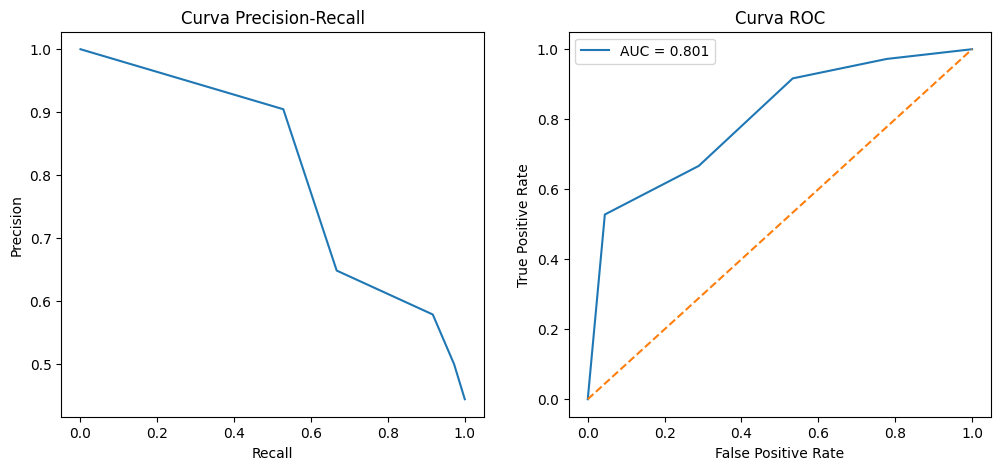

In [ ]:
plt.figure(figsize=(12,5))

# Precision-Recall
plt.subplot(1,2,1)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")

# ROC
plt.subplot(1,2,2)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()

plt.show()

Curva Precision–Recall:
A precisão é alta para valores menores de recall, mas diminui à medida que o recall aumenta, indicando um trade-off entre precisão e recall.

Curva ROC:
O modelo apresentou AUC = 0,801, indicando boa capacidade de distinguir entre as classes e desempenho melhor que um classificador aleatório.

Resumo:
O modelo apresenta desempenho satisfatório, conseguindo separar razoavelmente bem as classes, embora aumentar o recall possa reduzir a precisão.

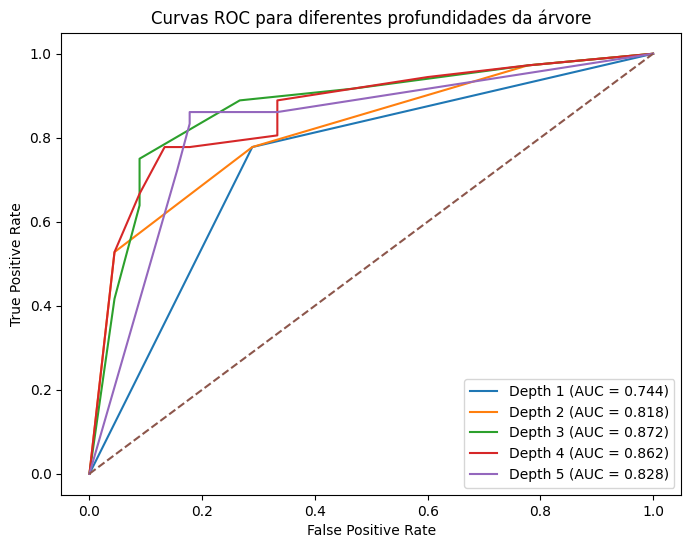

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc

depths = [1,2,3,4,5]

plt.figure(figsize=(8,6))

for d in depths:

    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    y_scores = model.predict_proba(X_test)[:,1]

    fpr, tpr, thresholds = roc_curve(y_test, y_scores, pos_label='yes')
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Depth {d} (AUC = {roc_auc:.3f})")

# linha de referência
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC para diferentes profundidades da árvore")
plt.legend()

plt.show()

A árvore com profundidade 3 apresentou o maior AUC (0,872), indicando a melhor capacidade de distinguir entre as classes. A profundidade 4 apresentou desempenho semelhante (AUC = 0,862), enquanto profundidades maiores ou menores apresentaram valores de AUC inferiores.

Resultado: Isso indica que profundidades intermediárias produzem melhor desempenho, enquanto árvores muito rasas ou muito profundas podem ter desempenho inferior na tarefa de classificação.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# probabilidades da classe positiva
y_scores = dt.predict_proba(X_test)[:,1]

thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]

results = []

for t in thresholds:

    y_pred = np.where(y_scores >= t, 'yes', 'no')

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label='yes')
    rec = recall_score(y_test, y_pred, pos_label='yes')
    f1 = f1_score(y_test, y_pred, pos_label='yes')

    results.append([t, acc, prec, rec, f1])

threshold_table = pd.DataFrame(
    results,
    columns=['Threshold','Accuracy','Precision','Recall','F1']
)

threshold_table

,Threshold,Accuracy,Precision,Recall,F1
0,0.1,0.56,0.50,0.97,0.66
1,0.3,0.67,0.58,0.92,0.71
2,0.5,0.69,0.65,0.67,0.66
3,0.7,0.77,0.90,0.53,0.67
4,0.9,0.77,0.90,0.53,0.67


Limiares baixos, como 0,1, apresentam recall muito alto (0,97), indicando que quase todos os casos positivos são identificados. No entanto, isso ocorre às custas de baixa precisão (0,50) e menor acurácia, pois o modelo tende a classificar muitos exemplos como positivos.

À medida que o threshold aumenta, a precisão melhora, chegando a 0,90 para thresholds de 0,7 e 0,9, enquanto o recall diminui para 0,53, indicando que menos casos positivos são identificados.

De forma geral, valores intermediários de threshold oferecem um equilíbrio entre precisão e recall, enquanto valores muito baixos priorizam recall e valores altos priorizam precisão.

**6. Utilize a validação cruzada para avaliar um conjunto de modelos utilizando diferentes métricas. Por fim, monte uma tabela com os resultados.**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
cv_lr = cross_val_score(lr, X_scaled, y, cv=5, scoring='accuracy')


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

dt = DecisionTreeClassifier(max_depth=3)
rf = RandomForestClassifier(n_estimators=100)
knn = KNeighborsClassifier()
lr = LogisticRegression(max_iter=5000)

In [ ]:
X = df.drop(columns=['class'])
y = df['class']

In [ ]:
from sklearn.model_selection import cross_val_score

cv_dt = cross_val_score(dt, X, y, cv=5, scoring='accuracy')
cv_rf = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
cv_knn = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
cv_lr = cross_val_score(lr, X, y, cv=5, scoring='accuracy')

In [ ]:
cv_dt.mean()
cv_rf.mean()
cv_knn.mean()
cv_lr.mean()

np.float64(0.8444444444444444)

In [ ]:
cv_results = pd.DataFrame({
    "Accuracy":[
        cv_dt.mean(),
        cv_rf.mean(),
        cv_knn.mean(),
        cv_lr.mean()
    ]
}, index=["DT","RF","KNN","LR"])

cv_results.round(3)

,Accuracy
DT,0.80
RF,0.83
KNN,0.68
LR,0.84


Regressão Logística (LR) apresentou o melhor desempenho, com acurácia de 0,84, seguida pelo Random Forest (RF) com 0,83. Esses resultados indicam que esses modelos conseguem classificar corretamente a maior parte das instâncias do conjunto de dados.

Árvore de Decisão (DT) apresentou um desempenho intermediário, com acurácia de 0,80, enquanto o KNN apresentou o menor desempenho, com acurácia de 0,68.

Resultados: Indicam que LR e RF são os modelos com melhor desempenho para este conjunto de dados, enquanto o KNN apresentou menor capacidade de classificação em comparação aos demais modelos.